In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.style.use("ggplot")

In [3]:
df = pd.read_csv("../data/processed/cleaned_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month,DayOfWeek,Hour,IsWeekend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,December,Tuesday,7,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,December,Tuesday,7,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,December,Tuesday,7,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,December,Tuesday,7,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,December,Tuesday,7,0


In [4]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [5]:
rfm = df.groupby("Customer ID").agg({

    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,

    "Invoice": "nunique",

    "Revenue": "sum"

})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [6]:
rfm.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,201.331916,6.289384,3018.616737
std,209.338707,13.009406,14737.731040
min,1.000000,1.000000,2.950000
25%,26.000000,1.000000,348.762500
50%,96.000000,3.000000,898.915000
75%,380.000000,7.000000,2307.090000
max,739.000000,398.000000,608821.650000


In [7]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [8]:
inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(rfm_scaled)

    inertia.append(model.inertia_)

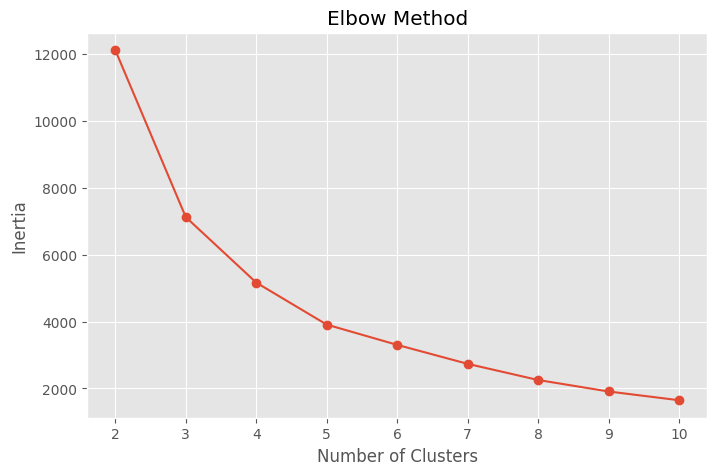

In [9]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), inertia, marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [10]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
12346.0,326,12,77556.46,1
12347.0,2,8,5633.32,1
12348.0,75,5,2019.40,1
12349.0,19,4,4428.69,1
12350.0,310,1,334.40,0


In [11]:
rfm["Cluster"].value_counts()

Cluster
1    3841
0    1998
2      35
3       4
Name: count, dtype: int64

In [13]:
cluster_summary = rfm.groupby("Cluster").mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,463.032032,2.212212,765.244446
1,67.005728,7.307732,3009.402451
2,25.942857,103.714286,83086.079771
3,3.500000,212.500000,436835.792500


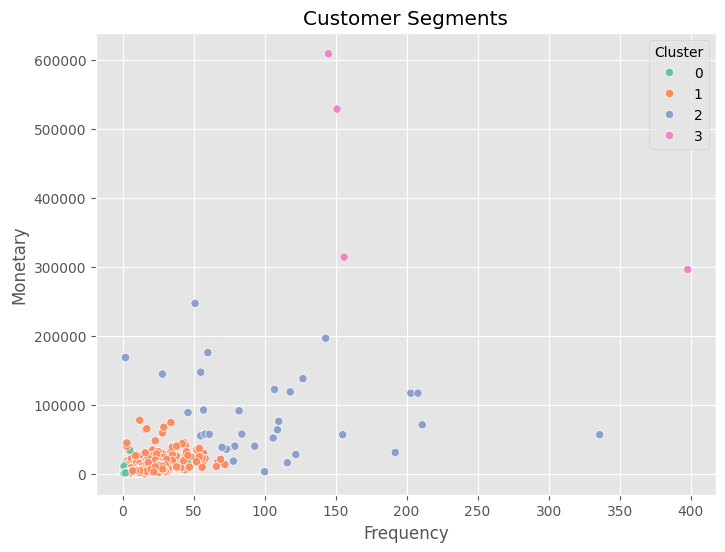

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments")

plt.show()

In [15]:
cluster_names = {
    0: "Regular",
    1: "VIP",
    2: "At Risk",
    3: "Loyal"
}

rfm["CustomerSegment"] = rfm["Cluster"].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,CustomerSegment
Customer ID,,,,,
12346.0,326,12,77556.46,1,VIP
12347.0,2,8,5633.32,1,VIP
12348.0,75,5,2019.40,1,VIP
12349.0,19,4,4428.69,1,VIP
12350.0,310,1,334.40,0,Regular


In [16]:
rfm["CustomerSegment"].value_counts()

CustomerSegment
VIP        3841
Regular    1998
At Risk      35
Loyal         4
Name: count, dtype: int64

In [17]:
rfm.to_csv(
    "../data/processed/customer_segments.csv"
)

print("Customer Segmentation Completed Successfully!")

Customer Segmentation Completed Successfully!
